<a href="https://colab.research.google.com/github/guupiii/ESAA/blob/main/ESAA_OB_week6_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**4.1 인공 신경망의 한계와 딥러닝 출현**

퍼셉트론은 다수의 신호를 입력으로 받아 하나의 신호를 출력하는데, 이 신호를 입력으로 받아 정보를 앞으로 전달하는 원리로 작동합니다.

AND 게이트 : 모든 입력이 1일때 작동합니다.

OR 게이트 : 입력에서 둘 중 하나만 1이거나 둘 다 1일 때 작동합니다.

XOR 게이트 : 배타적 논리합이라는 용어로 입력 두 개 중 한 개만 '1'일 때 작동하는 논리 연산입니다. 비선형적으로 분리되기 때문에 제대로 된 분류가 어렵습니다.

이를 극복하는 방안으로 입력층과 출력층 사이에 하나 이상의 중간층(은닉층)을 두어 비선형적으로 분리되는 데이터에 대해서도 학습이 가능하도록 다층 퍼셉트론을 고안
했습니다. 이때 입력층과 출력층 사이에 은닉층이 여러 개 있는 신경망을 심층 신경망이라고 하며 심층 신경망을 다른 이름으로 답러닝이라고 합니다.





**4.2.1 딥러닝 용어**

답러닝은 다음 그림과 같이 입력층 출력층과 두 개 이상의 은닉층으로 구성되어 있습니다.

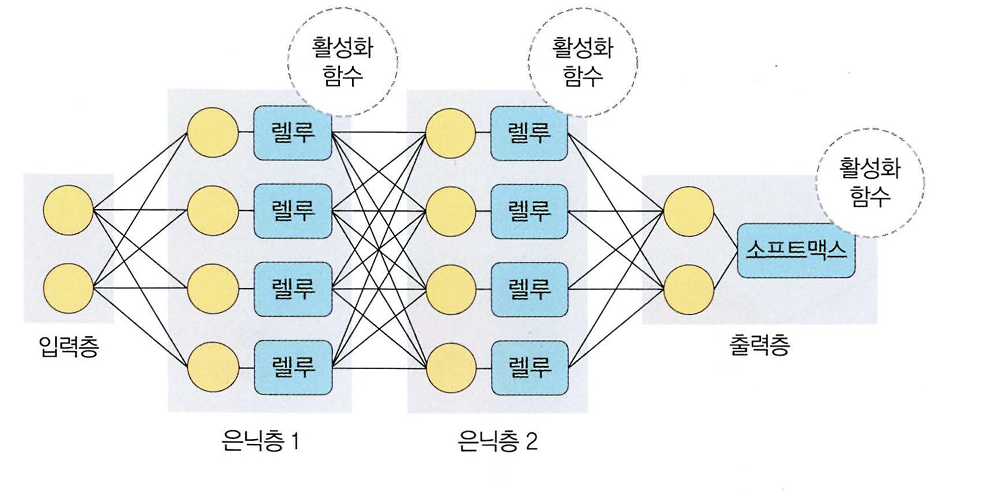

가중치 : 가중치는 입력 값이 연산 결과에 미치는 영향력을 조절하는 요소입니다.

가중합 또는 전달함수 : 가중합은 전달함수라고도 합니다. 각 노드에서 들어오는 신호에 가중치를 곱해서 다음 노드로 전달되는데, 이 값들을 모두 더한 합계를 가중합이라고 합니다.

활성화 함수 : 전달 함수에서 전달받은 값을 출력할 때 일정 기준에 따라 출력 값을 변화시키는 비선형 함수입니다. 시그모이드, 하이퍼볼릭 탄젠트, 렐루 함수 등이 있습니다.

시그모이드 함수 : 선형 함수의 결과를 0~1 사이에서 비선형 상태로 변형해 줍니다. 주로 로지스틱 회귀와 같은 분류 문제를 확률적으로 표현하는데 사용됩니다.
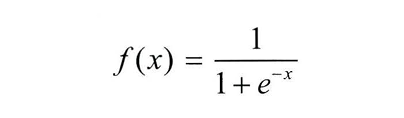

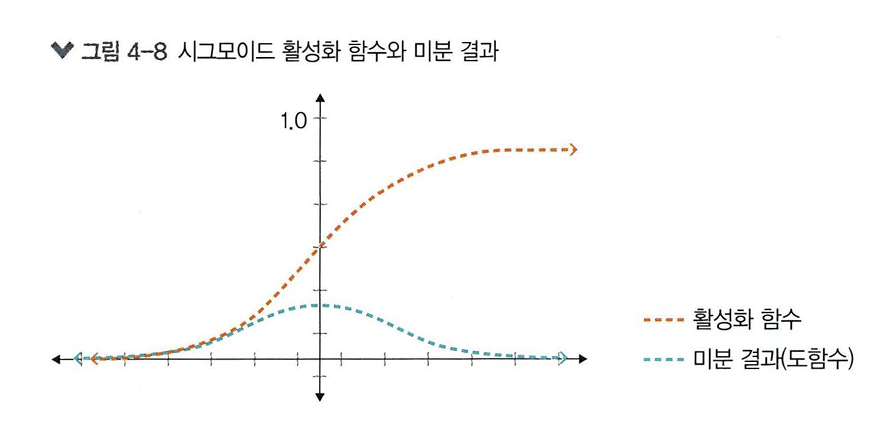

하이퍼볼랙 탄젠트 함수 : 선형 함수의 결과를 -1~1 사이에서 비선형 형태로 변형해 줍니다. 시그모이드 결과값의 평균이 0이 아닌 양수로 편향된 문제를 해결하는 데 사용했지만, 기울기 소멸 문제는 여전히 발생합니다.



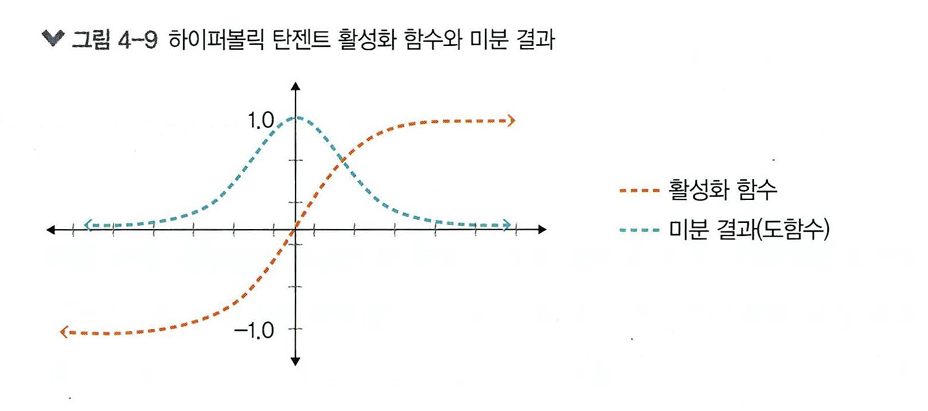

렐루 함수 : 입력이 음수일 때는 0을 출력하고, 양수일 때는 x를 출력합니다. 경사 하강법에 영향을 주지 않아 학습 속도가 빠르고, 기울기 소멸 문제가 발생하지 않는 장점이 있습니다.  렐루 함수는 일반적으로 은닉층에서 사용되며， 하이퍼볼릭 탄젠트함수대비 학습속도가6배 빠릅니다 문제는 음수값을 입력받으면 항상 0을 출력하기 때문에 학습능력이 감소하는데 이를 해결하려고 리키 렐루(Leaky ReLU) 함수 등을 사용합니다.

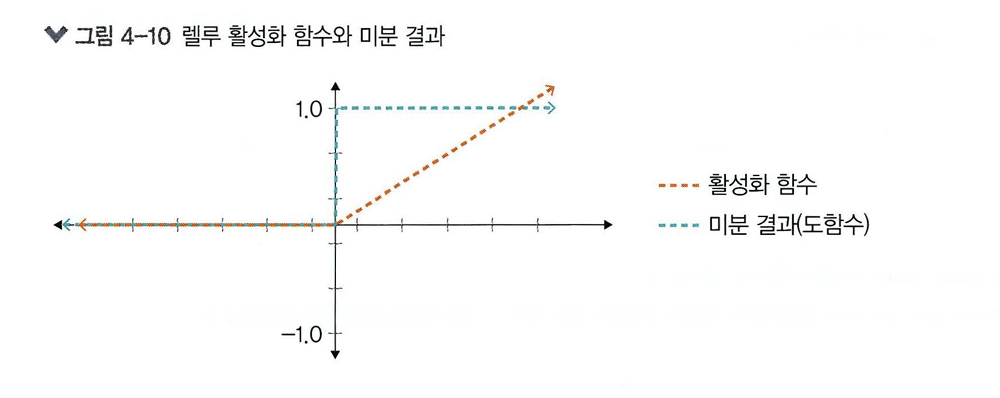

리키 렐루 함수 : 입력 값이 음수이면 0이 아닌 0.001처럼 매우 작은 수를 반환합니다. 이렇게 하면 입력 값이 수렴하는 구간이 제거되어 렐루 함수를 사용할 때 생기는 문제를 해결할 수 있습니다.

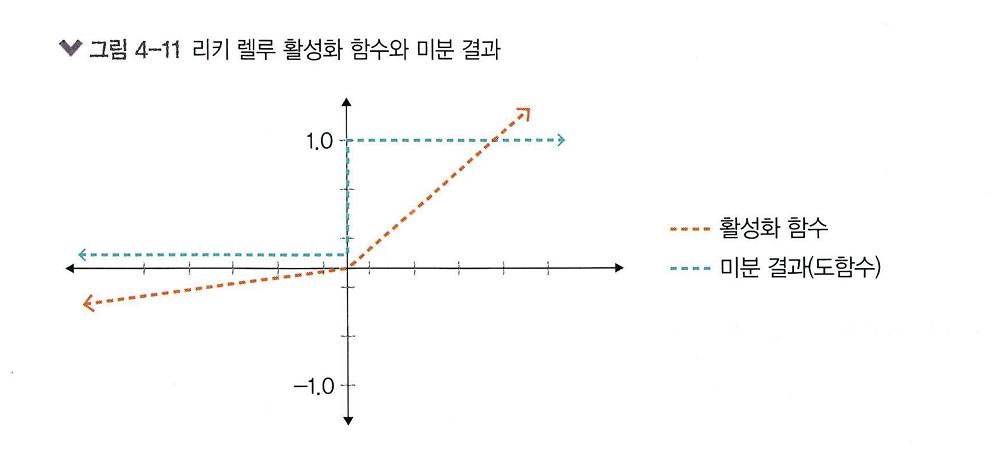

소프트맥스 함수 :  입력 값을 0~1 사이에 출력되도록 정규화하여 출력 값들의 총합이 항상1이 되도록 합니다. 소프트맥스 함수는보통 답러닝에서 출력 노드의 활성화함수로 많이 사용됩니다. 수식으로 표현하면 다음과 같습니다.

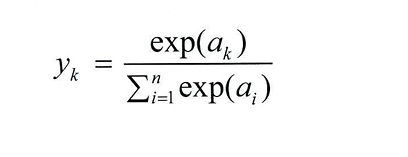

In [4]:
import torch
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_hidden, n_output):
        super(Net, self).__init__()
        self.hidden = torch.nn.Linear(n_feature, n_hidden)
        self.relu = torch.nn.ReLu(inplace=True )
        self.out = torch.nn.Linear( n_hidden, n_output)
        self.softmax = torch.nn.Softmax(dim=n_output)
    def forward (self, x):
        X = self.hidden(x)
        x = self.relu(x)
        x = self.out (x)
        x = se1f.softmax(x)
        return x

손실 함수 : 경사 하강법은 학습률과 손실 함수의 순간 기울기를 이용하여 가중치를 업데이트하는 방법입니다. 즉 미분의 기울기를 이용하여 오차를 비교하고 최소화하는 방향으로 이동시키는 방법이라고 할 수 있습니다. 이때 오치를 구하는 방법이 손실 함수입니다.  

평균 제곱 오차 : 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 것이 평균 제곡 오차 입니다.



In [6]:
#loss_fn = torch.nn.MSELoss(reduction = 'sum')
#y_pred = model(x)
#loss = loss_fn(y_pred, y)

**크로스 엔트로피 오차**

일반적으로 평균 제곱 오차 손실 함수와 시그모이드 활성화 함수를 결합하여 사용하면 시그모이 드의 특성으로 기울기가 매끄럽지 못한 울퉁불퉁한 상태이며 학습 속도도 매우 늦습니다. 이러한 단점을 극복한 것이 크로스 엔트로피 오차입니다. 크로스 엔트로피 오치는 두 개의 확
률 분포 차이를 이용하기 때문에 시그모이드의 영향을 덜 받습니다. 따라서 평균 제곱 오차보다 학습 속도가 빠른 장점이 있습니다.

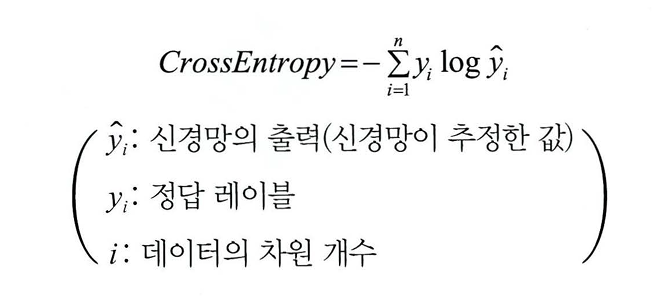

In [7]:
# 1055 = nn.CrossentropyLoss()
# input =  torch.randn(5, 6, requires_grad=True )
# target = torch.empty(3, dtype=torch.long).random_(5)
# output = loss(input, target)
# output.backward()



#**4.2.2 딥러닝 학습**

딥러닝 학습은 크게 순전파와 역전파라는 두 단계로 진행됩니다.
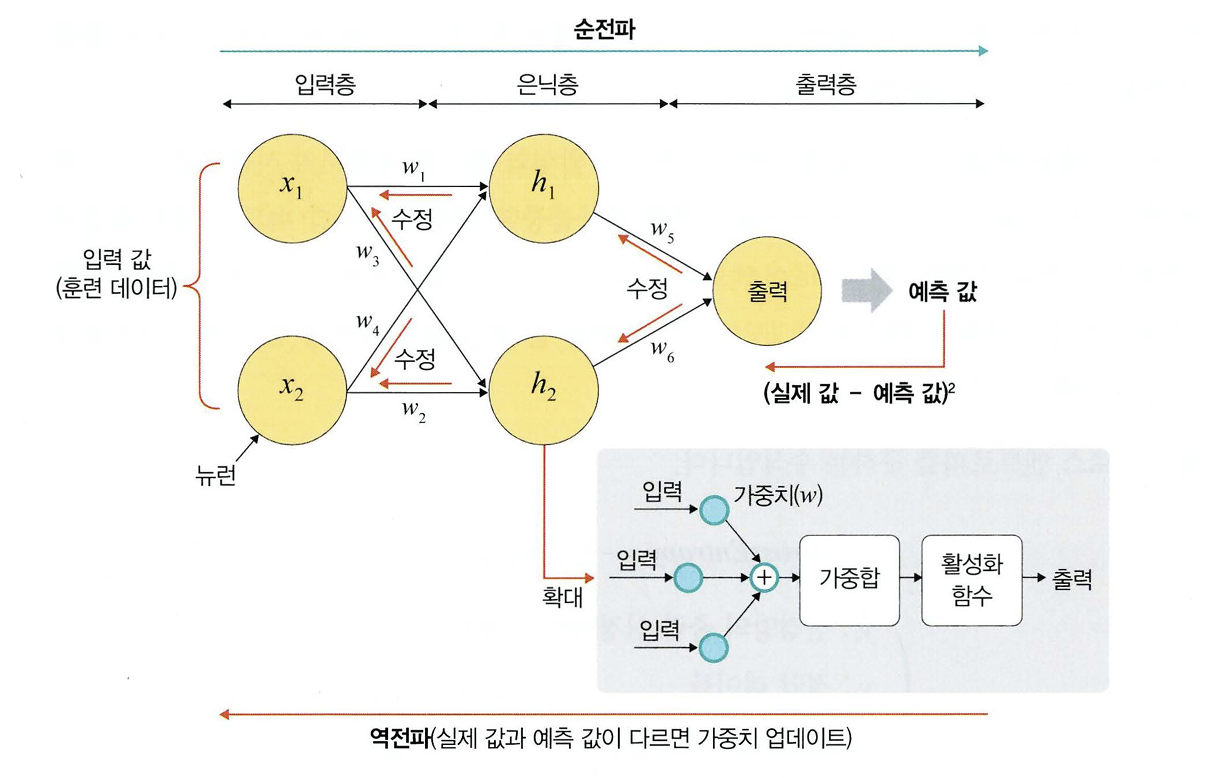

첫 번째 단계인 순전파는 네트워크에 훈련 데이터가 들어올 때 발생하며， 데이터를 기반으로 예측 값을 계산하기 위해 전체 신경망을 교차해 지나갑니다. 즉 모든 뉴런이 이전 층의 뉴런에서 수신한 정보에 변환(가중합 및 활성화 함수)을 적용하여 다음 층(은닉층)의 뉴런으로 전송
하는 방식입니다. 네트워크를 통해 입력 데이터를 전달하며 데이터가 모든 층을 통과하고 모든 뉴런이 계산을 완료하면 그 예측 값은 최종 층(출력층)에 도달하게 됩니다.

그다음 손실 함수로 네트워크의 예측 값과 실제 값의 차이(손실 오차)를 추정합니다. 이때 손실 함수 비용은 0이 이상적입니다. 따라서 손실 함수 비용이 0에 가깝도록 하기 위해 모델이 훈련을 반복하면서 가중치를 조정합니다. 손실이 계산되면 그 정보는 역으로 전파되기 때문에 역전파라고 합니다.


**4.2.3 딥러닝 문제점과 해결 방안**

답러닝의 핵심은 활성화 함수가 적용된 여러 은닉층을 결합하여 비선형 영역을 표현하는 것입니
다.

과적합 문제 발생 :

과적합은 훈련 데이터를 과하게 학습해서 발생합니다. 일반적으로 훈련 데이터는 실제 데이터의 일부분입니다. 따라서 훈련 데이터를 과하게 학습했기 때문에 예측 값과 실제 값 차이인 오차가 감소하지만 검증 데이터에 대해서는 오차가 증가할 수 있습니다.

In [ ]:
#class DropoutModel (torch .nn .Module ):
#    def __init__(self):
#        super(DropoutModel , self).__init__ ()
#        self.layer1 = torch.nn.Linear(784, 1200)
#        self. dropout1 = torch. nn.Dropout(0.5)
#        self.layer2 = torch.nn.Linear(1200, 1200)
#        self.dropout2 = torch.nn.Dropout(0.5)
#        self.layer3 = torch.nn.Linear(1200, 10)
#    def forward(self, x):
#        x = F.relu(self.layer1(x))
#        x = self.dropout1(x)
#        x = F.relu(self.layer2(x))
#        x = self.dropout2(x)
#        return self.layer3(x)

**기울기 소멸 문제 발생**

기울기 소멸 문제는 은닉층이 많은 신경망에서 주로 발생하는데， 출력층에서 은닉층으로 전달되는
오차가 크게 줄어들어 학습이 되지 않는 현상입니다. 즉， 기울기가 소멸되기 때문에 학습되는 양이 0에 가까워져 학습이 더디게 진행되 오차를 더 줄이지 못하고 그 상태로 수렴하는 현상입니다. 기울기 소멸 문제는 시그모이드나 하이퍼볼릭 탄젠트 대신 렐루 활성화 함수를 사용하면 해결할 수 있습니다.

**성능이 나빠지는 문제 발생**

경사 하강법은 손실 함수의 비용이 최소가 되는 지점을 찾을 때까지 기울기가 낮은 쪽으로 계속 이동시키는 과정을 반복하는데， 이때 성능이 나빠지는 문제가 발생합니다.

배치 경사 하강법 : 전체 데이터셋에 대한 오류를 구한 후 기울기를 한 번만 계산하여 모델의 파라미터를 업데이트 하는 방법입니다. 즉 전체 훈련 데이터셋에 대해 가중치를 편미분하는 방법입니다.

확률적 경사 하강법 : 임의로 선택한 데이터에 대해 기울기를 계산하는 방법으로 적은 데이터를 사용하므로 빠른 계산이 가능합니다.

미니 배치 경사 하강법 : 전체 데이터셋을 미니 배치 여러개로 나누고 미니 배치 한 개마다 기울기를 구한 후 그것의 평균 기울기를 이용하여 모델을 업데이트해서 학습합니다.




In [ ]:
#class CustomDataset(Dataset):
#    def __init__(self):
#        self.x_data = [[ 1, 2, 3], [4, 5, 6], [7 , 8, 9]]
#        self.y_data = [[ 12], [18 ], [11]]
#        def __len__(self):
#            return len (self.x_data)
#        def __getitem__ (self, idx):
#            x = torch.FloatTensor(self.x_data[idx])
#            y = torch.FloatTensor(self.y_data[idx])
#            return x, y
#dataset = CustomDataset()
#dataloader = DataLoader(
#153
#dataset,
#batch_size=2,
#shuffle=True, )

**4.2.4딥러닝을 사용할 때 이점**

특성 추출 : 컴퓨터가 입력받은 데이터를 분석하여 일정한 패턴이나 규칙을 찾아내려면 사람이 인지하는 데이터를 컴퓨터가 인지할 수 있는 데이터로 변환해 주어야 합니다. 이때 데이터별로 어떤 특정을 가지고 있는지 찾아내고 그것을 토대로 데이터를 벡터로 변환하는 작업을 특성 추출이라고 합니다.

#**4.3 딥러닝 알고리즘**

**4.3.1 심층 신경망**

심층 신경망(DNN)은 입력층과 출력층 사이에 다수의 은닉층을 포함하는 인공 신경망입니다.
다수의 은닉층을 두었기 때문에 다양한 비선형적 관계를 학습할 수 있는 장점이 있지만, 학습을
위한 연산량이 많고 기울기 소멸 문제 등이 발생할 수 있습니다. 이러한 문제를 해결하고자 앞서
설명한 드롭아웃, 렐루 함수, 배치 정규화 등을 적용해야 합니다.


**4.3.2 합성곱 신경망**

합성곱 신경망은 합성곱층과 풀링층을 포함하는 이미지 처리 성능이 좋은 인공 신경망 알고리즘입니다. 영상 및 사진이 포함된 이미지 데이터에서 객체를 탐색하거나 객체 위치를 찾아내는 데 유용한 신경망입니다.


**4.3.3. 순환 신경망**

순환신경망은 시계열 데이터 같은 시간의 흐름에 따라 변화하는 데이터를 학습하기 위한 인공 신경망입니다. 따라서 다음 그림과 같이 순환 신경망의 순환은 자기 자신을 참조한다는 것으로, 현재 결과가 이전 결과와 연관이 있다는 의미입니다.

**4.3.4 제한된 볼츠만 머신**

볼츠만 머신은 가시층과 은닉층이으로 구성된 모델입니다. 이 모텔에서 가시층은 은닉층과만 연결되는데 이것이 제한된 볼츠만 머신입니다.



**4.3.5 심층 신뢰 신경망**

심층 신뢰 신경망은 입력층과 은닉층으로 구성된 제한된 볼츠만 머신을 블록처럼 여러 층으로 쌓은 형태로 연결된 신경망입니다. 즉， 사전 훈련된 제한된 볼츠만 머신
을 층층이 쌓아 올린 구조로 레이블이 없는 데이터에 대한 비지도 학습이 가능합니다. 부분적인 이미지에서 전제를 연상하는 일반화와 추상화 과정을 구현할 때 사용하면 유용합니다.